In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv(
    r'D:\traning\online_retail.csv',
    sep=',',
    encoding='utf-8'
)

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


Let us assume that when we referred the matter back to the person responsible for data entry—specifically regarding the error where a negative sign was assigned to a number within the set of negative-signed values

In [8]:
df[df['UnitPrice']<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [9]:
df[df['CustomerID'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,NaN,United Kingdom


In [10]:
df[df['Quantity']<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [11]:
df['Quantity'] = np.float64(df['Quantity'].astype(str).str.replace('-', ''))
df['UnitPrice'] = np.float64( df['UnitPrice'].astype(str).str.replace('-', ''))
        

Let us assume that when we consulted the person responsible for data entry, it turned out they had forgotten to populate the `customer_id` column. Furthermore, there was an error on the part of the database administrator, who should have designated this column as the primary key.

In [12]:
df = df.dropna(subset=['CustomerID'])

Question 2 : Descriptive statistics: average purchase value, purchase frequency, customer  lifetime value

In [13]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
purchase_value = df.groupby('InvoiceNo')['TotalPrice'].sum().mean()

In [14]:
float (purchase_value)

429.1460114465975

In [15]:
purchase_freq=float(df.groupby('CustomerID')['InvoiceNo'].nunique().mean())


In [16]:
clv = purchase_value * purchase_freq

print(clv)

2178.122139524245


Question 3 : Feature selection: identify 2–3 key behavioural features for clustering (e.g., Recency, Frequency, Monetary — RFM analysis) 

In [17]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
snapshot_date = df['InvoiceDate'].max()


recency = df.groupby('CustomerID')['InvoiceDate'].max().apply(
    lambda x: (snapshot_date - x).days
)

In [18]:
recency

CustomerID
12346.0    325
12347.0      1
12348.0     74
12349.0     18
12350.0    309
          ... 
18280.0    277
18281.0    180
18282.0      7
18283.0      3
18287.0     42
Name: InvoiceDate, Length: 4372, dtype: int64

In [19]:
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

In [20]:
frequency

CustomerID
12346.0     2
12347.0     7
12348.0     4
12349.0     1
12350.0     1
           ..
18280.0     1
18281.0     1
18282.0     3
18283.0    16
18287.0     3
Name: InvoiceNo, Length: 4372, dtype: int64

In [21]:
monetary = df.groupby('CustomerID')['TotalPrice'].sum()

In [22]:
monetary

CustomerID
12346.0    154367.20
12347.0      4310.00
12348.0      1797.24
12349.0      1757.55
12350.0       334.40
             ...    
18280.0       180.60
18281.0        80.82
18282.0       179.50
18283.0      2094.88
18287.0      1837.28
Name: TotalPrice, Length: 4372, dtype: float64

Question 4: Data normalisation/standardisation before clustering (use StandardScaler) 

In [23]:
rfm = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
})

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,2,154367.20
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [24]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
rfm_scaled =scale.fit_transform(rfm)

In [25]:
rfm_scaled

array([[ 2.32202285e+00, -3.29362146e-01,  1.44927426e+01],
       [-8.93733232e-01,  2.06102417e-01,  2.03015601e-01],
       [-1.69195597e-01, -1.15176321e-01, -3.62708473e-02],
       ...,
       [-8.34182193e-01, -2.22269234e-01, -1.90325854e-01],
       [-8.73882885e-01,  1.16993863e+00, -7.92702681e-03],
       [-4.86801135e-01, -2.22269234e-01, -3.24578968e-02]])

Question 5 : Apply K-Means clustering — use the Elbow Method to determine optimal number of clusters (K) 

In [26]:
from sklearn.cluster import KMeans
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

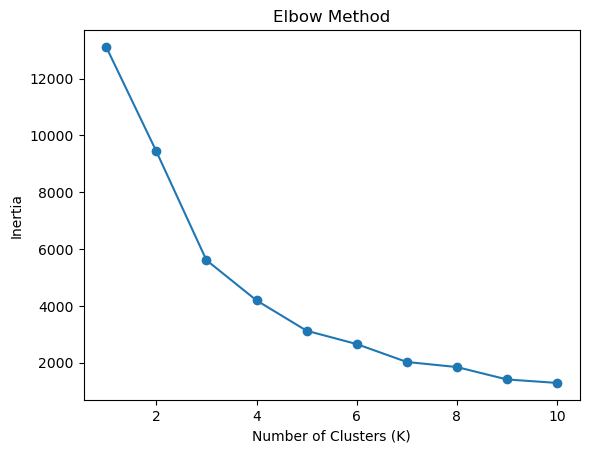

In [28]:
plt.figure()
plt.plot(range(1, 11) , inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [29]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [30]:
rfm

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,325,2,154367.20,2
12347.0,1,7,4310.00,0
12348.0,74,4,1797.24,0
12349.0,18,1,1757.55,0
12350.0,309,1,334.40,1
...,...,...,...,...
18280.0,277,1,180.60,1
18281.0,180,1,80.82,1
18282.0,7,3,179.50,0


In [43]:
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()

columns = ['Recency','Frequency','Monetary']

data = pd.DataFrame(scale.fit_transform(rfm[columns]), columns=columns)


In [48]:
data['Cluster'] = rfm['Cluster'].values

In [49]:
data

,Recency,Frequency,Monetary,Cluster
0,2.322023,-0.329362,14.492743,2
1,-0.893733,0.206102,0.203016,0
2,-0.169196,-0.115176,-0.036271,0
3,-0.725005,-0.436455,-0.040050,0
4,2.163220,-0.436455,-0.175575,1
...,...,...,...,...
4367,1.845615,-0.436455,-0.190221,1
4368,0.882873,-0.436455,-0.199723,1
4369,-0.834182,-0.222269,-0.190326,0
4370,-0.873883,1.169939,-0.007927,0


Question 6 : Visualise clusters using scatter plots (at least 2 feature combinations) 


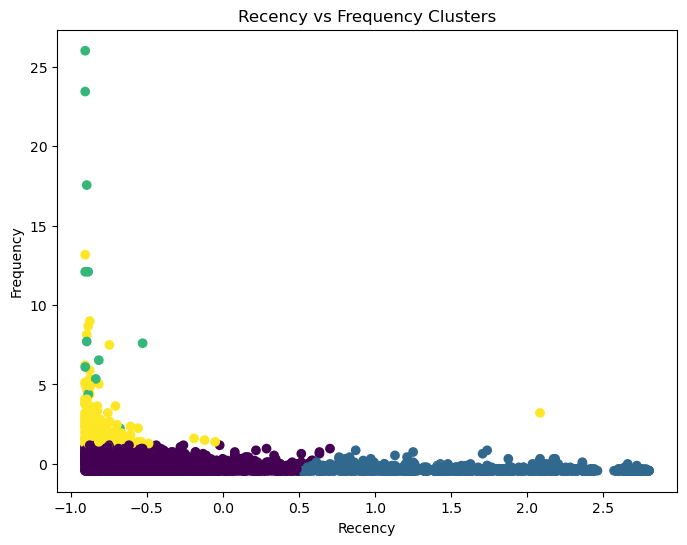

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(data['Recency'], data['Frequency'], 
            c=data['Cluster'], cmap='viridis')

plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.title('Recency vs Frequency Clusters')
plt.show()

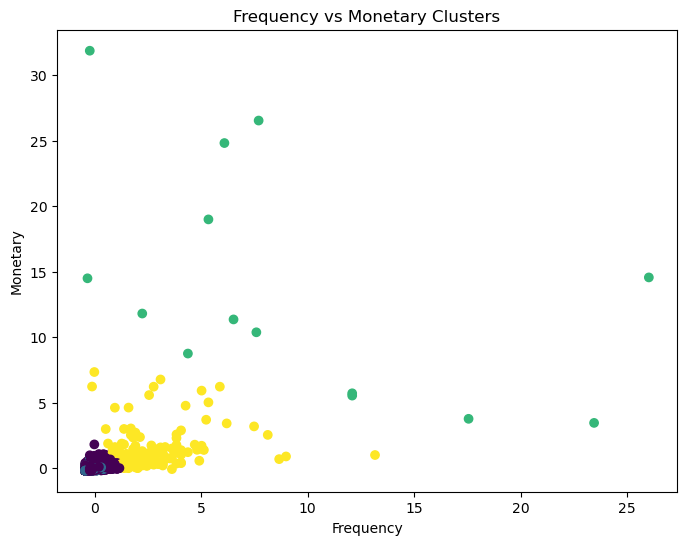

In [59]:
plt.figure(figsize=(8,6))
plt.scatter(data['Frequency'], data['Monetary'], 
            c=data['Cluster'], cmap='viridis')

plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Frequency vs Monetary Clusters')
plt.show()

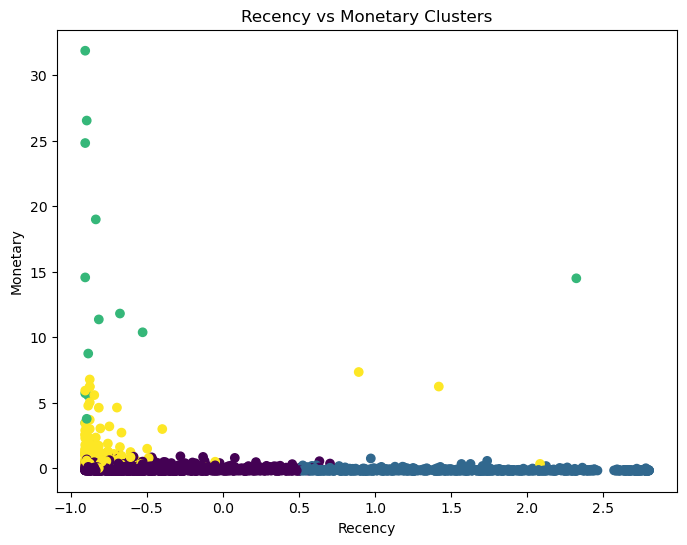

In [51]:
plt.figure(figsize=(8,6))
plt.scatter(data['Recency'], data['Monetary'], 
            c=data['Cluster'], cmap='viridis')

plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.title('Recency vs Monetary Clusters')
plt.show()

 Question 7 : Profile each cluster: calculate mean feature values per cluster and describe the customer type

In [52]:
cluster_profile = data.groupby('Cluster').mean()
print(cluster_profile)

          Recency  Frequency   Monetary
Cluster                                
0       -0.486555  -0.085296  -0.077252
1        1.558081  -0.350621  -0.160942
2       -0.614411   9.324299  13.714533
3       -0.785563   2.338090   1.003202


Question 8 : Bar chart: number of customers per cluster 

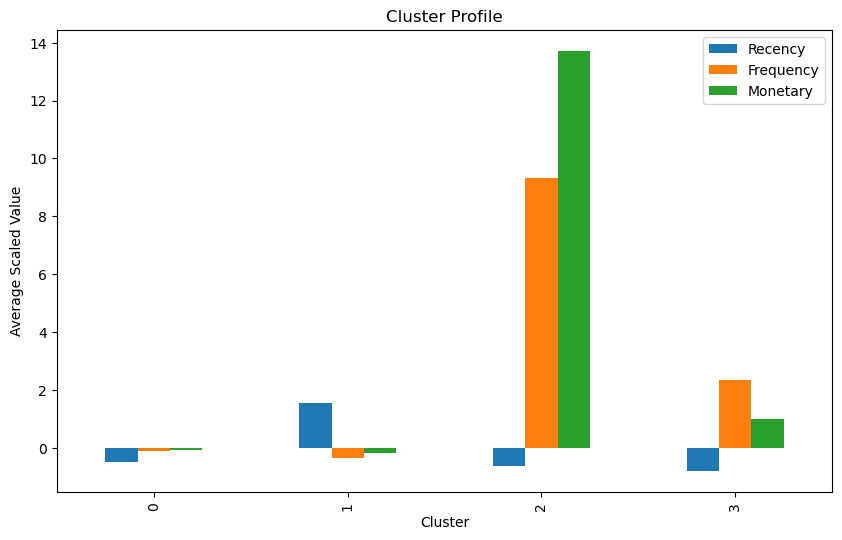

In [53]:
cluster_profile.plot(kind='bar', figsize=(10,6))
plt.title('Cluster Profile')
plt.ylabel('Average Scaled Value')
plt.show()

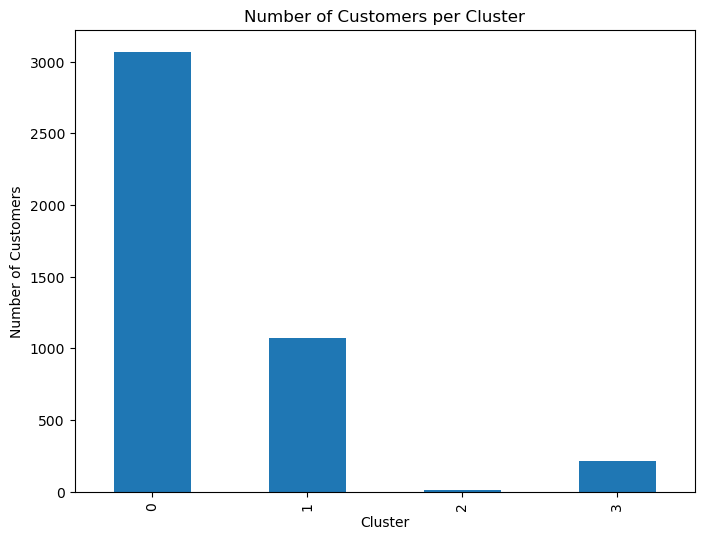

In [56]:
cluster_counts = data['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8,6))
cluster_counts.plot(kind='bar')

plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers per Cluster')

plt.show()

Question 9 : Insights section: what marketing action would you recommend for each segment?

Insights & Marketing Recommendations per Cluster

Customer segmentation using RFM analysis and K-Means clustering enables businesses to better understand customer behavior and apply targeted marketing strategies. Based on the clustering results, the following insights and actions are recommended:

💎 Cluster 1: VIP Customers

Characteristics:

Low Recency (recent purchases)
High Frequency
High Monetary value

Insights:
These are the most valuable customers who purchase frequently and spend the most.

Recommended Actions:

Implement loyalty programs and rewards
Offer exclusive deals and early access to new products
Use personalized email marketing
Provide premium customer service

👉 Goal: Retain and maximize lifetime value (CLV)

⚠️ Cluster 2: Lost / Inactive Customers

Characteristics:

High Recency (no recent purchases)
Low Frequency
Low Monetary value

Insights:
These customers have stopped engaging and may churn.

Recommended Actions:

Launch reactivation campaigns
Offer strong discounts or promotions
Send reminder emails or notifications
Use retargeting ads

👉 Goal: Re-engage and win back customers

🌱 Cluster 3: New / Low-Value Customers

Characteristics:

Low Frequency
Low Monetary value
Recently acquired customers

Insights:
These customers are at an early stage and need nurturing.

Recommended Actions:

Provide welcome offers and onboarding emails
Offer incentives like free shipping
Educate them about products/services
Encourage repeat purchases

👉 Goal: Convert them into loyal customers

🔄 Cluster 4: Regular Customers

Characteristics:

متوسطين في Recency, Frequency, Monetary

Insights:
These customers are consistent but not highly engaged.

Recommended Actions:

Apply upselling and cross-selling strategies
Recommend relevant products
Offer personalized discounts
Increase engagement through targeted campaigns

👉 Goal: Increase spending and engagement

🧠 Key Business Insight

Customer segmentation allows businesses to deliver personalized marketing strategies, leading to improved customer retention, increased revenue, and more efficient allocation of marketing resources.